# 02 — Parameter Estimation

**Goal:** Formally estimate the key model parameters — drift (μ) and volatility (σ) — from the play-by-play data.

**What we're doing:**
- Load all play-by-play data and compute per-minute margin changes
- Estimate σ rigorously (per quarter, overall, with confidence intervals)
- Estimate μ from pre-game spreads
- Validate that our Brownian motion assumptions hold

**Prerequisites:** `01_data_exploration.ipynb` run, `play_by_play` table populated.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import norm

import sys
sys.path.insert(0, str(Path('..').resolve()))

from infra.db import queries

DB_PATH = '../data/quant_lab.db'

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

print('Setup complete.')

Setup complete.


In [2]:
from nba_api.stats.static import teams as nba_teams_static

nba_teams = nba_teams_static.get_teams()
teams_df = pd.DataFrame(nba_teams)[['id', 'full_name', 'abbreviation']]
teams_df['id'] = teams_df['id'].astype(str)
teams_df = teams_df.rename(columns={'id': 'team_id', 'full_name': 'team_name'})

## Load games and play-by-play data

In [3]:
games = queries.get_games(DB_PATH, league='NBA')

games = games.merge(
    teams_df.rename(columns={'team_id': 'home_team_id', 'team_name': 'home_team_name', 'abbreviation': 'home_abbrev'}),
    on='home_team_id', how='left'
)
games = games.merge(
    teams_df.rename(columns={'team_id': 'away_team_id', 'team_name': 'away_team_name', 'abbreviation': 'away_abbrev'}),
    on='away_team_id', how='left'
)

print(f"Total NBA games: {len(games)}")
print(f"Date range: {games['game_date'].min()} → {games['game_date'].max()}")
games.head()

Total NBA games: 1225
Date range: 2024-10-22 → 2025-04-13


,game_id,league,season,game_date,home_team_id,away_team_id,home_final_score,away_final_score,pre_game_spread,pre_game_total,status,home_team_name,home_abbrev,away_team_name,away_abbrev
0,0022400061,NBA,2024-25,2024-10-22,1610612738,1610612752,NaN,NaN,None,None,final,Boston Celtics,BOS,New York Knicks,NYK
1,0022400062,NBA,2024-25,2024-10-22,1610612747,1610612750,NaN,NaN,None,None,final,Los Angeles Lakers,LAL,Minnesota Timberwolves,MIN
2,0022400069,NBA,2024-25,2024-10-23,1610612740,1610612741,123.0,111.0,None,None,final,New Orleans Pelicans,NOP,Chicago Bulls,CHI
3,0022400065,NBA,2024-25,2024-10-23,1610612748,1610612753,97.0,116.0,None,None,final,Miami Heat,MIA,Orlando Magic,ORL
4,0022400072,NBA,2024-25,2024-10-23,1610612757,1610612744,104.0,140.0,None,None,final,Portland Trail Blazers,POR,Golden State Warriors,GSW


In [4]:
pbp_all = queries.get_play_by_play_for_sigma(DB_PATH, league='NBA')
pbp_all = pbp_all.sort_values(['game_id', 'elapsed_minutes'])

print(f"Total PBP rows: {len(pbp_all):,}")
print(f"Games covered: {pbp_all['game_id'].nunique():,}")
pbp_all.head()

Total PBP rows: 603,951
Games covered: 1,225


,game_id,elapsed_minutes,score_margin,quarter
0,0022400001,0.000000,0,1
1,0022400001,0.000000,0,1
2,0022400001,0.283333,0,1
3,0022400001,0.283333,0,1
4,0022400001,0.300000,0,1


## 1. Bucket games into 1-minute intervals

Raw play-by-play has one row per *play event* — events are irregularly spaced in time. To model score differential as a discrete random walk, we need evenly-spaced observations.

**Method:** floor `elapsed_minutes` into integer bins, then take the **last** score margin reading within each bin. Taking the last (rather than mean or first) gives us the true state of the game at the end of each minute, which is what matters for a Markov model.

Each resulting row represents: *"at the end of minute k in game g, the margin was X."*

`bucket_game_minutes(pbp)` works on any slice of the data — pass the full `pbp_all` to process every game at once, or a filtered subset to inspect a single game.

In [ ]:
def bucket_game_minutes(pbp: pd.DataFrame) -> pd.DataFrame:
    """
    Bucket play-by-play rows into 1-minute intervals.
    Returns one row per (game_id, minute_bucket) with the end-of-minute score margin.
    Works on a single game or the full dataset.
    """
    pbp = pbp.copy()
    pbp['minute_bucket'] = pbp['elapsed_minutes'].apply(np.floor).astype(int)
    return (
        pbp
        .groupby(['game_id', 'minute_bucket'])['score_margin']
        .last()
        .reset_index()
    )


def compute_margin_changes(minute_margins: pd.DataFrame) -> pd.Series:
    """
    Compute per-minute score margin changes within each game.
    The first minute of each game is dropped (no prior minute to diff against).
    Returns a flat Series of margin changes across all games.
    """
    changes = minute_margins.groupby('game_id')['score_margin'].diff()
    return changes.dropna()


# Run on the full dataset
minute_margins = bucket_game_minutes(pbp_all)
margin_changes = compute_margin_changes(minute_margins)

print(f"Minute buckets total:  {len(minute_margins):,}")
print(f"Margin changes total:  {len(margin_changes):,}  (one fewer per game due to diff)")
print(f"\nSample — first game bucketed:")
minute_margins[minute_margins['game_id'] == pbp_all['game_id'].iloc[0]].head(10)

In [ ]:
def plot_minute_margins(pbp: pd.DataFrame, game_id: str) -> None:
    """
    Plot the end-of-minute score margins for a single game after bucketing.
    Pass the full pbp_all DataFrame and a game_id string.
    """
    single_game = pbp[pbp['game_id'] == game_id]
    if single_game.empty:
        print(f"No PBP data found for game {game_id}")
        return

    bucketed = bucket_game_minutes(single_game)

    game_row = games[games['game_id'] == game_id]
    if not game_row.empty:
        home = game_row.iloc[0]['home_team_name']
        away = game_row.iloc[0]['away_team_name']
        title = f'Minute-by-minute margin — {home} vs {away} ({game_id})'
    else:
        title = f'Minute-by-minute margin — Game {game_id}'

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.step(bucketed['minute_bucket'], bucketed['score_margin'],
            where='post', linewidth=1.5, color='steelblue')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    for q_end in [12, 24, 36, 48]:
        ax.axvline(q_end, color='lightgray', linestyle=':', linewidth=1)

    ax.set_xlabel('Elapsed minutes (game clock)')
    ax.set_ylabel('Score margin (home − away)')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    final_margin = bucketed['score_margin'].iloc[-1]
    print(f"Final margin: {int(final_margin):+d} ({'home win' if final_margin > 0 else 'away win'})")


# Example — change game_id to any game in the dataset
plot_minute_margins(pbp_all, games.iloc[0]['game_id'])

## 2. Estimate σ — baseline volatility

Under our Brownian motion model, the score differential evolves as:

$$dX(t) = \mu \, dt + \sigma \, dW(t)$$

The 1-minute margin changes we just computed are discrete samples of $dX$. If the model holds, these should be approximately normally distributed with:
- **Mean ≈ 0** across a balanced dataset (home and away teams are symmetric on average)
- **Std = σ** — the quantity we want to estimate

`estimate_sigma` computes this and prints a quick sanity check.

In [9]:
def estimate_sigma(margin_changes: pd.Series) -> float:
    """
    Estimate σ as the standard deviation of 1-minute margin changes.
    Prints mean and sample size as a sanity check.
    Returns σ in units of points per √minute.
    """
    sigma = margin_changes.std()
    print(f"N:     {len(margin_changes):,}")
    print(f"Mean:  {margin_changes.mean():.4f}  (expect ~0 for balanced dataset)")
    print(f"σ:     {sigma:.4f} points/√min")
    return sigma


sigma = estimate_sigma(margin_changes)

N:     59,120
Mean:  0.0352  (expect ~0 for balanced dataset)
σ:     2.6269 points/√min


In [22]:
pbp_regulation = pbp_all[pbp_all['quarter'] <= 4]
regulation_changes = compute_margin_changes(bucket_game_minutes(pbp_regulation))

sigma = estimate_sigma(regulation_changes)
print(f"\n(Regulation-only baseline — used for all σ comparisons below)")

N:     58,800
Mean:  0.0354  (expect ~0 for balanced dataset)
σ:     2.6274 points/√min

(Regulation-only baseline — used for all σ comparisons below)


## 3. Pre-game spread data coverage

Before using spread-derived drift (μ) in the model, we need to know how many games actually have spread data. Games missing a spread cannot have a meaningful μ — and since the spread already prices in home court advantage, missing spreads also means we lose that correction.

Here we check: how many games have spread data, how many don't, and whether the missing data is concentrated in a particular part of the season (e.g. early season, when lines may not have been captured).

In [16]:
has_spread = games['pre_game_spread'].notna()

n_total    = len(games)
n_with     = has_spread.sum()
n_without  = (~has_spread).sum()

print(f"Total games:        {n_total:,}")
print(f"With spread:        {n_with:,}  ({n_with/n_total:.1%})")
print(f"Without spread:     {n_without:,}  ({n_without/n_total:.1%})")

# Break down missing spreads by month to spot temporal patterns
games['game_date'] = pd.to_datetime(games['game_date'])
games['month'] = games['game_date'].dt.to_period('M')

coverage_by_month = (
    games.groupby('month')
    .apply(lambda g: pd.Series({
        'total':    len(g),
        'with':     g['pre_game_spread'].notna().sum(),
        'without':  g['pre_game_spread'].isna().sum(),
        'pct_with': g['pre_game_spread'].notna().mean(),
    }), include_groups=False)
    .reset_index()
)

print()
print(coverage_by_month.to_string(index=False))

Total games:        1,225
With spread:        0  (0.0%)
Without spread:     1,225  (100.0%)

  month  total  with  without  pct_with
2024-10   71.0   0.0     71.0       0.0
2024-11  221.0   0.0    221.0       0.0
2024-12  189.0   0.0    189.0       0.0
2025-01  225.0   0.0    225.0       0.0
2025-02  176.0   0.0    176.0       0.0
2025-03  238.0   0.0    238.0       0.0
2025-04  105.0   0.0    105.0       0.0


## 4. σ by quarter

Our baseline σ treats all 48 minutes as homogeneous, but volatility may not be constant across the game. Late-game situations (foul hunting, intentional misses, garbage time) could produce systematically different per-minute score swings than early-game play.

`estimate_sigma_by_quarter` computes σ separately for each quarter, using the same bucketing and differencing logic but restricting to rows where the PBP quarter matches. This lets us check whether a single σ is a reasonable assumption or whether a quarter-varying model would be more accurate.

 quarter    sigma  n_changes  mean_change
       1 2.594980      14700     0.042925
       2 2.559206      14700     0.017279
       3 2.586710      14700     0.054082
       4 2.473323      14700     0.019184
       5 2.265369        300    -0.043333
       6 2.684752         20     0.050000


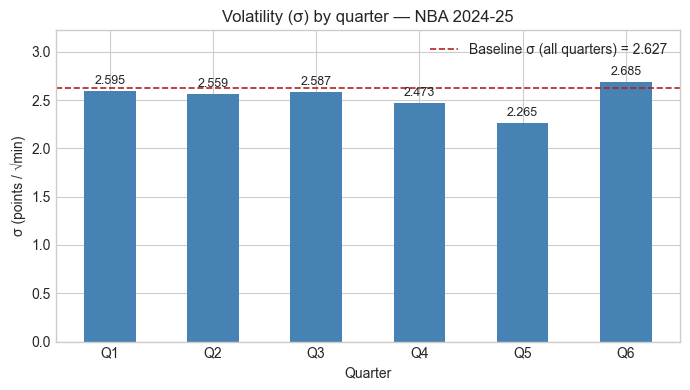

In [17]:
def estimate_sigma_by_quarter(pbp: pd.DataFrame) -> pd.DataFrame:
    """
    Estimate σ separately for each quarter.
    Accepts the same pbp DataFrame as bucket_game_minutes — full dataset or a single-game slice.
    Returns a DataFrame with columns: quarter, sigma, n_changes, mean_change.
    """
    results = []
    for quarter, group in pbp.groupby('quarter'):
        bucketed = bucket_game_minutes(group)
        changes = compute_margin_changes(bucketed)
        results.append({
            'quarter': int(quarter),
            'sigma': changes.std(),
            'n_changes': len(changes),
            'mean_change': changes.mean(),
        })
    return pd.DataFrame(results).sort_values('quarter').reset_index(drop=True)


sigma_by_quarter = estimate_sigma_by_quarter(pbp_all)
print(sigma_by_quarter.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))

quarters = sigma_by_quarter['quarter']
sigmas   = sigma_by_quarter['sigma']
bars = ax.bar(quarters, sigmas, color='steelblue', width=0.5)

ax.axhline(sigma, color='firebrick', linestyle='--', linewidth=1.2, label=f'Baseline σ (all quarters) = {sigma:.3f}')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)

ax.set_xticks(quarters)
ax.set_xticklabels([f'Q{q}' for q in quarters])
ax.set_xlabel('Quarter')
ax.set_ylabel('σ (points / √min)')
ax.set_title('Volatility (σ) by quarter — NBA 2024-25')
ax.legend()
ax.set_ylim(0, sigmas.max() * 1.2)

plt.tight_layout()
plt.show()

### Summary of the results

Here is the printed summary of the estimated sigma by quarter:

| quarter  |  sigma   | n_changes  | mean_change |
|----------|----------|------------|-------------|
|    1     | 2.594980 |   14700    |   0.042925  |
|    2     | 2.559206 |   14700    |   0.017279  |
|    3     | 2.586710 |   14700    |   0.054082  |  
|    4     | 2.473323 |   14700    |   0.019184  |
|    5     | 2.265369 |     300    |  -0.043333  |
|    6     | 2.684752 |      20    |   0.050000  |

### 4b. σ by quarter — excluding final 2 minutes of Q2 and Q4

The end of Q2 and Q4 are the most structurally distorted periods: both halves close with timeouts, strategic fouling, and clock stoppages that compress the number of possessions per game-clock minute. Q4 is the most extreme case; Q2 has a milder version of the same effect.

Here we strip those final 2 minutes out (elapsed minutes 22–24 for Q2, 46–48 for Q4) and re-estimate σ per quarter. If the Q2 and Q4 bars rise toward the Q1/Q3 levels, it confirms that the late-period mechanics — not genuine defensive intensity — were driving the suppression.

 quarter    sigma  n_changes  mean_change
       1 2.594980      14700     0.042925
       2 2.659703      11025     0.028571
       3 2.586710      14700     0.054082
       4 2.571699      11025     0.004989
       5 2.265369        300    -0.043333
       6 2.684752         20     0.050000


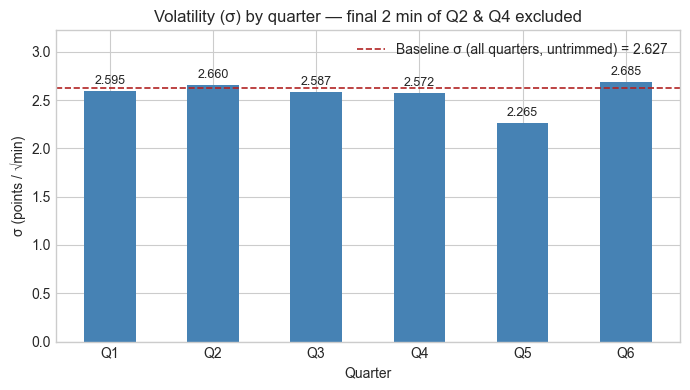

In [18]:
pbp_trimmed = pbp_all[
    ~((pbp_all['quarter'] == 2) & (pbp_all['elapsed_minutes'] >= 22)) &
    ~((pbp_all['quarter'] == 4) & (pbp_all['elapsed_minutes'] >= 46))
]

sigma_by_quarter_trimmed = estimate_sigma_by_quarter(pbp_trimmed)
print(sigma_by_quarter_trimmed.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))

quarters = sigma_by_quarter_trimmed['quarter']
sigmas   = sigma_by_quarter_trimmed['sigma']
bars = ax.bar(quarters, sigmas, color='steelblue', width=0.5)

ax.axhline(sigma, color='firebrick', linestyle='--', linewidth=1.2,
           label=f'Baseline σ (all quarters, untrimmed) = {sigma:.3f}')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)

ax.set_xticks(quarters)
ax.set_xticklabels([f'Q{q}' for q in quarters])
ax.set_xlabel('Quarter')
ax.set_ylabel('σ (points / √min)')
ax.set_title('Volatility (σ) by quarter — final 2 min of Q2 & Q4 excluded')
ax.legend()
ax.set_ylim(0, sigmas.max() * 1.2)

plt.tight_layout()
plt.show()

### A note

One thing to note here is that file historial_loader.py is never loading in the spread data — this can mean that any estimations for μ may not be accurate.